In [15]:
import os
import pyemu
import numpy as np
import matplotlib.pyplot as plt
from a_setup import *

# set working directory
os.chdir(r'C:\Users\tfo46\e_Python\a_rbm\rapid-gwm-build')

In [16]:
m_d = os.path.join(TEMP_DIR, '..', 'master_local')
pst_name = f'{MODEL_NAME}.pst'
pst = pyemu.Pst(os.path.join(TEMP_DIR, pst_name))

In [17]:
#read the Jacobian matrix
jco = pyemu.Jco.from_binary(os.path.join(m_d,pst_name.replace(".pst",".jcb")))
jco_df = jco.to_dataframe()
# inspect the matrix as a dataframe
jco_df = jco_df.loc[pst.nnz_obs_names,:]
jco_df.head()

,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:25_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:35_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:45_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:55_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:15_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:25_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:35_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:45_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:55_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:25_j:5_zone:1,...,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:37_idx2:9,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:38_idx2:1,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:38_idx2:8,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:2,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:3,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:4,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:5,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:6,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:7,pname:drn_riv_condcn_inst:0_ptype:cn_usecol:4_pstyle:m
oname:cum_otype:lst_usecol:drn_totim:1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.323971,-1.851263e-01,0.347112,0.370253,0.000000,0.254549,0.092563,0.509097,-0.023141,-9682.268210
oname:cum_otype:lst_usecol:rcha_totim:1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
oname:cum_otype:lst_usecol:wel2_totim:1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
oname:cum_otype:lst_usecol:wel_totim:1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
oname:springobs_otype:lst_usecol:pk2_head_kper:0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.000560,7.599700e-07,-0.000504,-0.000591,-0.000101,-0.000402,-0.000195,-0.000645,-0.000015,4.746569


In [18]:
# instantiate schur
sc = pyemu.Schur(jco=os.path.join(m_d, pst_name.replace(".pst",".jcb")))

# calcualte the parameter CSS
css_df = sc.get_par_css_dataframe()
css_df.sort_values(by='pest_css', ascending=False).head()

,pest_css,hill_css
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:19_idx2:30,88.135550,0.0
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:17_idx2:27,88.098523,0.0
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:16_idx2:26,88.083376,0.0
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:28_idx2:31,88.070753,0.0
pname:drn_riv_condcn_inst:0_ptype:cn_usecol:4_pstyle:m,88.022761,0.0


In [19]:
css_df['grp_name'] = css_df.index.map(lambda x: x.split(':')[1][:-5])

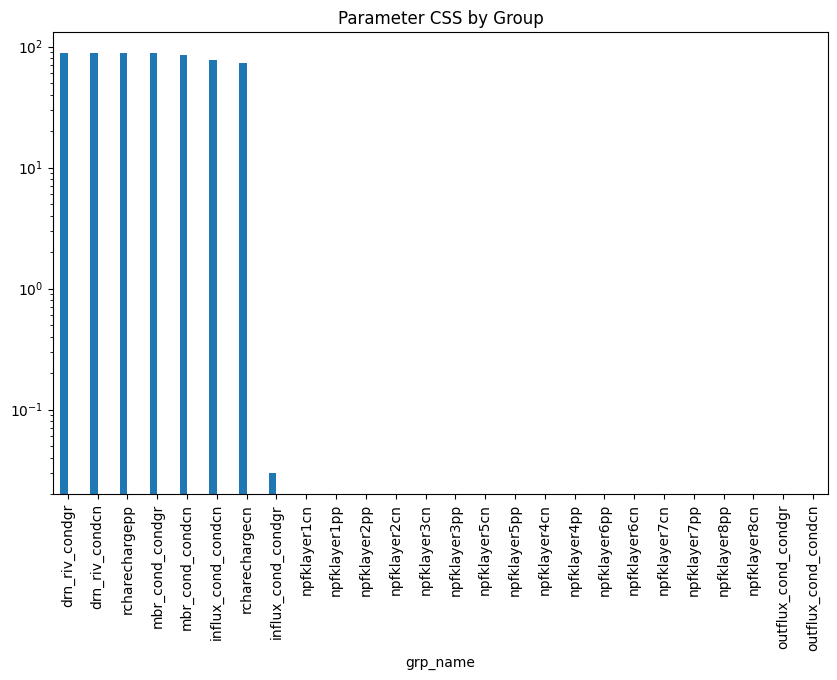

In [20]:
ax = css_df.groupby('grp_name').max().sort_values(by='pest_css', ascending=False).plot.bar(
    figsize=(10, 6), legend=False, title='Parameter CSS by Group', color='C0')
ax.set_yscale('log')

In [21]:
covar = pyemu.Cov(sc.xtqx.x, names=sc.xtqx.row_names)
covar.df().head()

,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:25_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:35_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:45_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:55_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:15_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:25_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:35_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:45_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:55_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:25_j:5_zone:1,...,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:37_idx2:9,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:38_idx2:1,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:38_idx2:8,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:2,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:3,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:4,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:5,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:6,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:7,pname:drn_riv_condcn_inst:0_ptype:cn_usecol:4_pstyle:m
pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:25_zone:1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:35_zone:1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:45_zone:1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:55_zone:1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:15_zone:1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


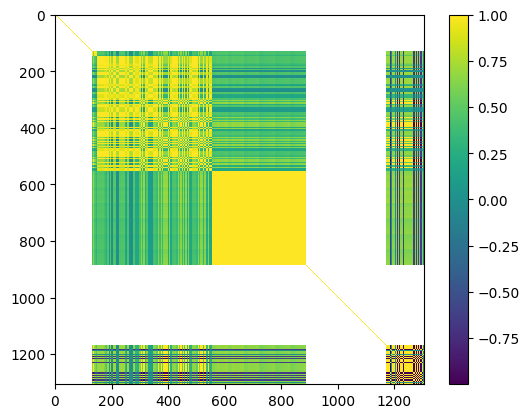

In [22]:
R = covar.to_pearson()
plt.imshow(R.df(), interpolation='nearest', cmap='viridis')
plt.colorbar()

In [23]:
cpar = R.df().index[500]
print(cpar)
R.df().loc[cpar][np.abs(R.df().loc[cpar])>.8]

pname:mbr_cond_condgr_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:5_idx1:23_idx2:40


pname:mbr_cond_condgr_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:0_idx1:16_idx2:47    0.980060
pname:mbr_cond_condgr_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:0_idx1:16_idx2:48    0.980062
pname:mbr_cond_condgr_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:0_idx1:16_idx2:49    0.980566
pname:mbr_cond_condgr_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:0_idx1:16_idx2:50    0.980568
pname:mbr_cond_condgr_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:0_idx1:17_idx2:52    0.981565
                                                                                    ...   
pname:mbr_cond_condgr_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:5_idx1:46_idx2:40    0.962085
pname:mbr_cond_condgr_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:5_idx1:47_idx2:39    0.960840
pname:mbr_cond_condgr_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:5_idx1:47_idx2:40    0.962093
pname:mbr_cond_condgr_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:5_idx1:48_idx2:39    0.960844
pname:mbr_cond_condgr_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:5_idx1:48_idx2:40    0.960844

In [24]:
cov_df = R.df()

In [25]:
cov_df[abs(cov_df.values) > 0.95]

,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:25_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:35_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:45_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:55_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:15_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:25_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:35_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:45_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:55_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:25_j:5_zone:1,...,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:37_idx2:9,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:38_idx2:1,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:38_idx2:8,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:2,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:3,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:4,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:5,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:6,pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:7,pname:drn_riv_condcn_inst:0_ptype:cn_usecol:4_pstyle:m
pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:25_zone:1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:35_zone:1,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:45_zone:1,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:55_zone:1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:15_zone:1,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pname:drn_riv_condcn_inst:0_ptype:cn_usecol:4_pstyle:m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.999842,0.999973,-0.999906,-0.999875,-0.006972,-0.999878,-0.99973,-0.999939,0.999852,1.0
pname:drn_riv_condcn_inst:0_ptype:cn_usecol:4_pstyle:m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.999842,0.999973,-0.999906,-0.999875,-0.006972,-0.999878,-0.99973,-0.999939,0.999852,1.0
pname:drn_riv_condcn_inst:0_ptype:cn_usecol:4_pstyle:m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.999842,0.999973,-0.999906,-0.999875,-0.006972,-0.999878,-0.99973,-0.999939,0.999852,1.0
pname:drn_riv_condcn_inst:0_ptype:cn_usecol:4_pstyle:m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.999842,0.999973,-0.999906,-0.999875,-0.006972,-0.999878,-0.99973,-0.999939,0.999852,1.0


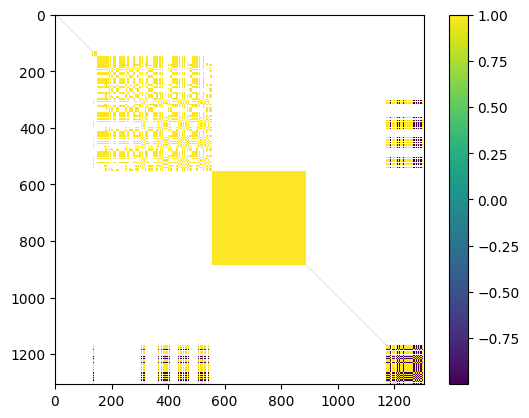

In [26]:
R_plot = R.as_2d.copy()
R_plot[np.abs(R_plot)<0.95] = np.nan
plt.imshow(R_plot, interpolation='nearest', cmap='viridis')
plt.colorbar();

In [27]:
import flopy

# import the model
sim = flopy.mf6.MFSimulation.load(sim_ws=TEMP_DIR)
gwf = sim.get_model(MODEL_NAME)


loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package npf...
    loading package ic...
    loading package rch...
    loading package drn...
    loading package chd...
    loading package chd...
    loading package wel...
    loading package wel...
    loading package wel...
    loading package oc...
  loading solution package local1...


In [28]:
iarr = gwf.dis.idomain.get_data()
iarr.shape

(8, 50, 61)

In [29]:
import numpy as np
# 1 - subset the df with just drn_riv_cond
css_df = css_df.loc[css_df.index.str.contains('drn_riv_condgr')]
css_df

,pest_css,hill_css,grp_name
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:2_idx2:47,0.000421,0.0,drn_riv_condgr
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:2_idx2:59,0.000631,0.0,drn_riv_condgr
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:2_idx2:60,0.000631,0.0,drn_riv_condgr
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:3_idx2:46,71.411022,0.0,drn_riv_condgr
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:3_idx2:57,87.909392,0.0,drn_riv_condgr
...,...,...,...
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:3,0.000013,0.0,drn_riv_condgr
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:4,0.002315,0.0,drn_riv_condgr
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:5,0.000842,0.0,drn_riv_condgr
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:6,0.004629,0.0,drn_riv_condgr


In [30]:
# idx0:0_idx1:39_idx2:7 split this into (0, 39, 7)
css_df['k'] = css_df.index.map(lambda x: int(x.split('_')[-3].split(':')[-1]))
css_df['i'] = css_df.index.map(lambda x: int(x.split('_')[-2].split(':')[-1]))
css_df['j'] = css_df.index.map(lambda x: int(x.split('_')[-1].split(':')[-1]))
css_df

,pest_css,hill_css,grp_name,k,i,j
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:2_idx2:47,0.000421,0.0,drn_riv_condgr,0,2,47
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:2_idx2:59,0.000631,0.0,drn_riv_condgr,0,2,59
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:2_idx2:60,0.000631,0.0,drn_riv_condgr,0,2,60
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:3_idx2:46,71.411022,0.0,drn_riv_condgr,0,3,46
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:3_idx2:57,87.909392,0.0,drn_riv_condgr,0,3,57
...,...,...,...,...,...,...
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:3,0.000013,0.0,drn_riv_condgr,0,39,3
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:4,0.002315,0.0,drn_riv_condgr,0,39,4
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:5,0.000842,0.0,drn_riv_condgr,0,39,5
pname:drn_riv_condgr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:39_idx2:6,0.004629,0.0,drn_riv_condgr,0,39,6


In [31]:
drn_css = np.ones_like(iarr) * 0
drn_css_bool = np.ones_like(iarr) * 0

# set the values in the array
for idx, row in css_df.iterrows():
    val = row['pest_css']
    drn_css_bool[int(row['k']), int(row['i']), int(row['j'])] = 1
    if val > 0.0:
        # set the value in the array
        drn_css[int(row['k']), int(row['i']), int(row['j'])] = val

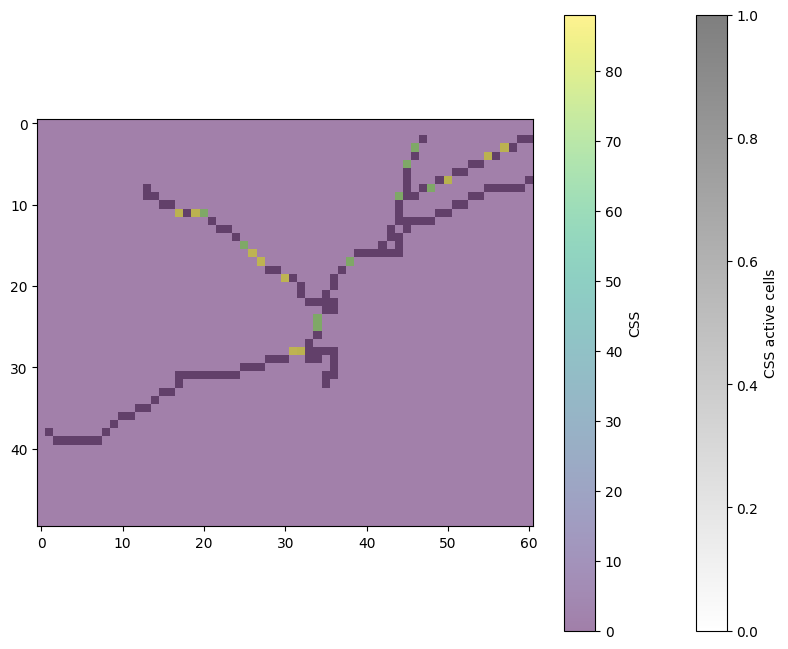

In [32]:
# plot the CSS
plt.figure(figsize=(10, 8))
plt.imshow(drn_css_bool[0, :, :], cmap='binary', alpha=0.5)
plt.colorbar(label='CSS active cells')
plt.imshow(drn_css[0, :, :], cmap='viridis', alpha=0.5)
plt.colorbar(label='CSS')

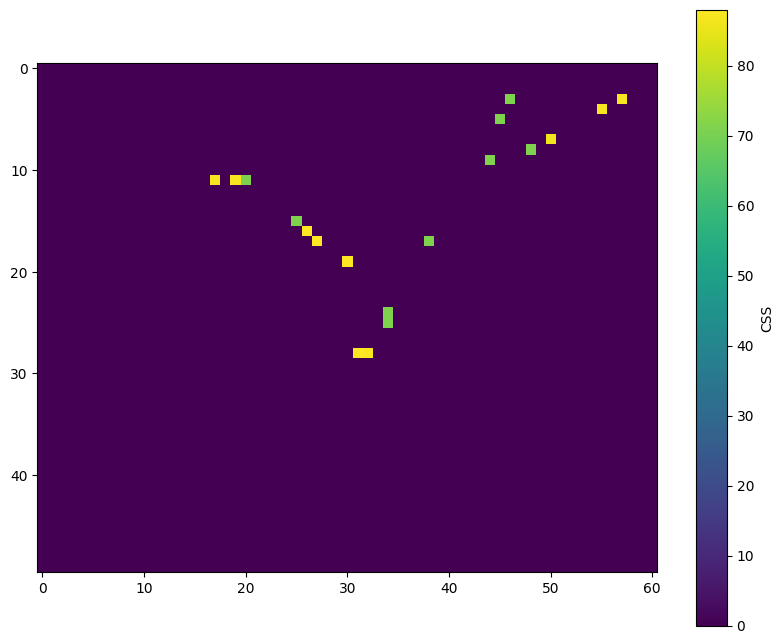

In [33]:
# plot the CSS
plt.figure(figsize=(10, 8))
plt.imshow(drn_css[0, :, :], cmap='viridis')
plt.colorbar(label='CSS')

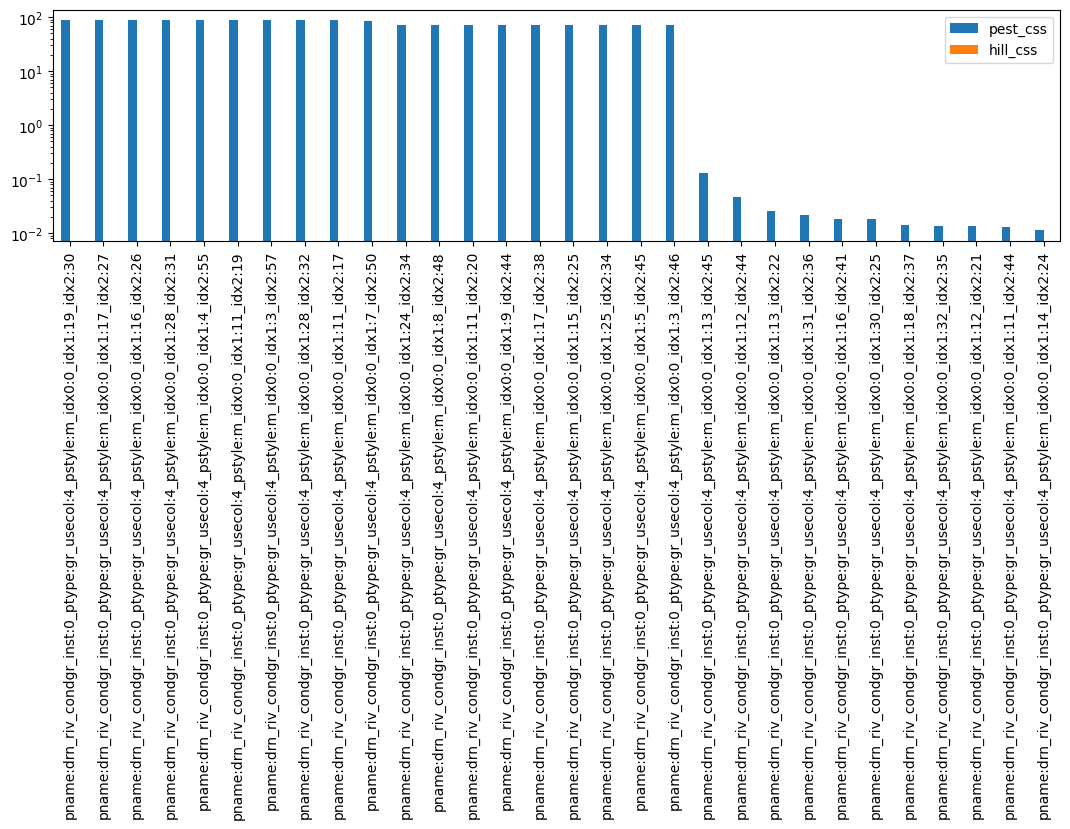

In [39]:
css_df[['pest_css', 'hill_css']].sort_values(by='pest_css', ascending=False).head(30).plot(kind='bar', figsize=(13,3))
plt.yscale('log')

## Identifiability

In [40]:
ev = pyemu.ErrVar(jco=os.path.join(m_d,pst_name.replace(".pst",".jcb")))

In [41]:
pst.nnz_obs

11

In [42]:
singular_value= 11

id_df = ev.get_identifiability_dataframe(singular_value=singular_value).sort_values(by='ident', ascending=False)
id_df.head()

,right_sing_vec_1,right_sing_vec_2,right_sing_vec_3,right_sing_vec_4,right_sing_vec_5,right_sing_vec_6,right_sing_vec_7,right_sing_vec_8,right_sing_vec_9,right_sing_vec_10,right_sing_vec_11,ident
pname:mbr_cond_condcn_inst:0_ptype:cn_usecol:3_pstyle:m,8.050605e-03,9.899112e-01,1.212317e-05,5.113257e-06,2.501502e-05,5.731288e-06,6.862667e-10,8.749927e-10,9.395504e-07,7.385202e-09,2.632866e-06,0.998013
pname:influx_cond_condcn_inst:0_ptype:cn_usecol:3_pstyle:m,6.903381e-03,1.205587e-04,9.899548e-01,5.797703e-07,5.161759e-07,1.213359e-10,9.831986e-10,3.057865e-09,2.589821e-08,1.238428e-09,2.853811e-08,0.996980
pname:rcharechargepp_inst:0_ptype:pp_pstyle:m_i:5_j:25_zone:1,1.857591e-08,7.455966e-10,4.943368e-09,4.602645e-03,4.376075e-04,5.500908e-05,2.208821e-04,1.333309e-05,6.887058e-06,9.892498e-01,0.000000e+00,0.994586
pname:rcharechargecn_inst:0_ptype:cn_pstyle:m,6.188562e-03,7.791839e-05,5.480515e-05,9.348367e-01,4.526995e-04,7.203940e-06,2.921217e-06,7.600317e-04,6.585217e-04,5.371521e-03,1.312370e-03,0.949723
pname:rcharechargepp_inst:0_ptype:pp_pstyle:m_i:5_j:35_zone:1,1.186930e-08,5.058725e-10,3.540324e-09,3.373325e-03,3.154767e-04,4.053560e-05,1.829668e-04,7.300718e-01,1.498593e-01,1.727668e-05,3.363020e-04,0.884197


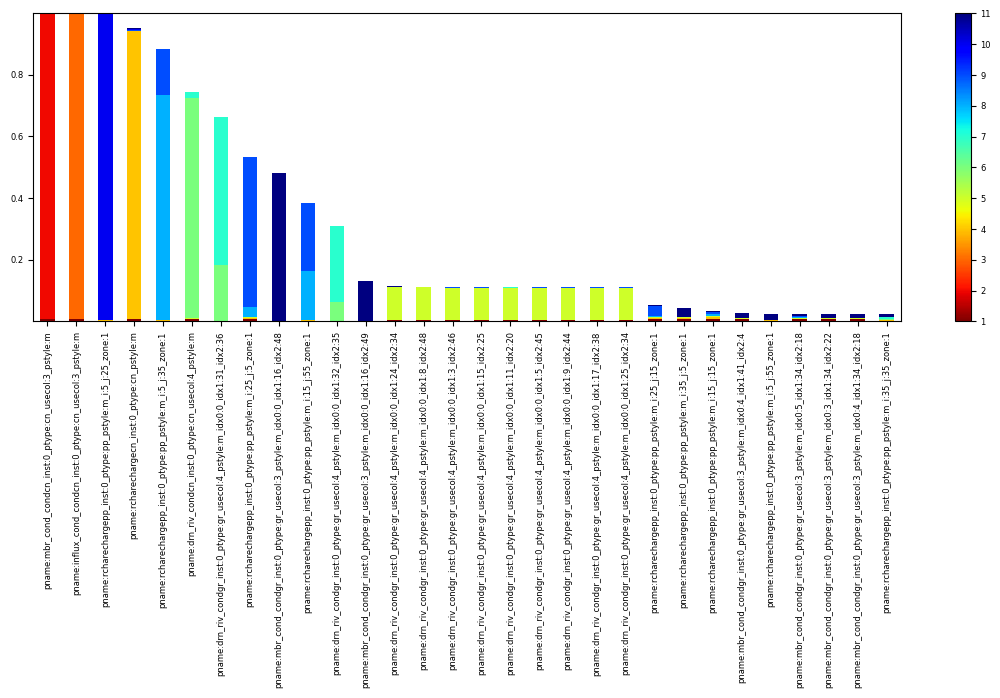

In [44]:
id = pyemu.plot_utils.plot_id_bar(id_df.head(30), figsize=(14,4))

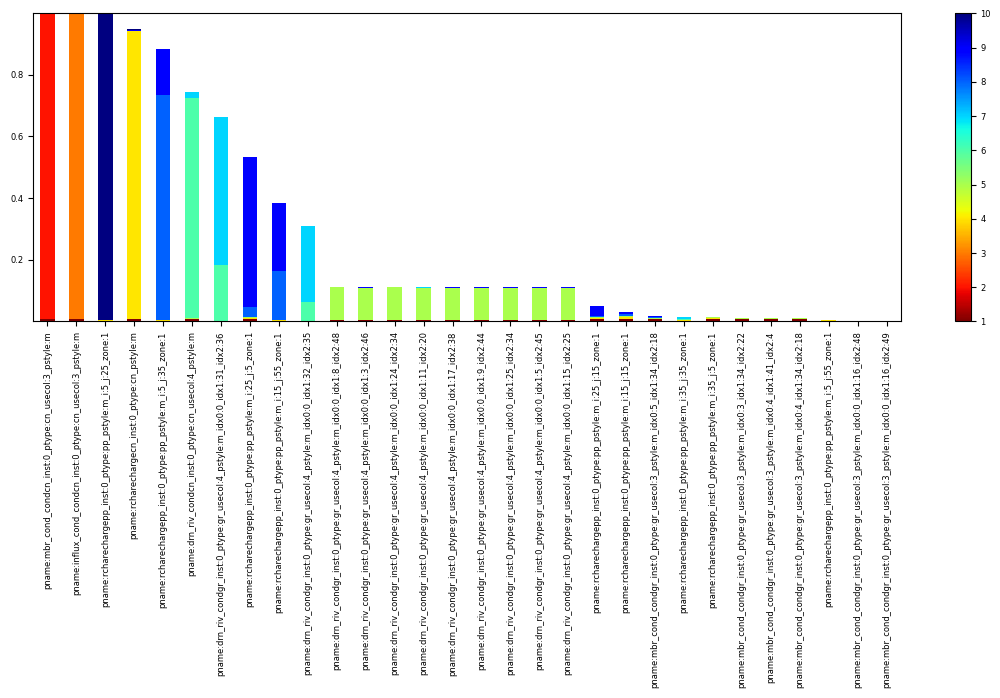

In [45]:
id = pyemu.plot_utils.plot_id_bar(id_df.head(30), nsv=10, figsize=(14,4))

# MC prep

In [ ]:
prior_cov = pyemu.Cov.from_parameter_data(pst)
x = prior_cov.as_2d.copy()
x[x==0] = np.nan
plt.imshow(x)
plt.colorbar();
parensemble = pyemu.ParameterEnsemble.from_gaussian_draw(pst=pst,cov=prior_cov,
                                                         num_reals=250)
# ensure that the samples respect parameter bounds in the pst control file
parensemble.enforce()

In [49]:
parensemble.head()

,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:25_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:35_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:45_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:5_j:55_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:15_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:25_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:35_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:45_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:15_j:55_zone:1,pname:npfklayer1pp_inst:0_ptype:pp_pstyle:m_i:25_j:5_zone:1,...,pname:chd_pw_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:40_idx2:41,pname:chd_pw_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:41_idx2:41,pname:chd_pw_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:42_idx2:41,pname:chd_pw_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:43_idx2:41,pname:chd_pw_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:44_idx2:41,pname:chd_pw_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:45_idx2:40,pname:chd_pw_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:46_idx2:40,pname:chd_pw_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:47_idx2:40,pname:chd_pw_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:48_idx2:40,pname:chd_pw_headcn_inst:0_ptype:cn_usecol:3_pstyle:a
0,0.360440,0.224043,1.854766,0.470412,10.625511,0.095809,5.228544,0.615393,0.092087,0.739764,...,0.942817,0.057858,-0.491210,-1.436289,-0.703877,1.086867,0.413586,-1.183414,0.065076,-0.010505
1,0.692935,0.346776,0.192127,6.867020,0.144570,0.787094,68.635464,5.973650,0.056463,1.119376,...,-2.000000,-0.178724,-1.387314,-0.420045,-0.003463,1.737546,-1.422150,0.452838,0.314423,0.228264
2,9.479075,2.973417,12.909729,0.019396,0.434573,0.554847,0.076316,0.632418,3.638692,0.372508,...,-0.372790,-0.461946,0.313295,0.591112,-1.166988,2.000000,-0.513173,0.843221,0.473931,2.000000
3,2.818737,0.041493,1.182462,11.029693,2.249953,4.656979,0.094604,29.093575,0.318602,0.278476,...,-0.671070,-1.197727,-0.480454,-0.461863,-0.513778,-0.295104,-0.345153,-0.114657,0.419908,0.349412
4,3.770476,8.198277,0.371966,0.046619,0.488363,56.484069,3.592947,4.621214,1.720971,1.666349,...,-0.631902,0.506282,-1.227266,0.816278,1.129359,1.623388,1.761286,0.812264,0.722663,0.461781


In [59]:
par = pst.parameter_data
parnmes = par.loc[par.pargp=='hk1'].parnme.values
pe_k = parensemble.loc[:,parnmes].copy()
TEMP_DIR = r"C:\Users\tfo46\e_Python\a_rbm\rapid-gwm-build\examples\manual_builds\models\local1\pest\local1_template"
# use the hbd convenienc function to plot several realisations
plot_ensemble_arr(pe_k, TEMP_DIR, 10, 'local1', 'npfklayer1pp_inst0pp.dat')

   could not remove start_datetime
return type uncaught, losing Ensemble type, returning DataFrame


c:\Users\tfo46\e_Python\a_rbm\rapid-gwm-build\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame


ValueError: Length of values (0) does not match length of index (16)

<Figure size 1200x1000 with 0 Axes>